In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax
from fewjaxstudy.waveform import build_waveform_from_coefficients, construct_amplitude_phase_splines
jax.config.update("jax_enable_x64", True)

In [2]:
from fewjaxstudy.trajectory.ode import get_trajectory_generator
traj_gen = get_trajectory_generator("../amps-prep/KerrEccEqFluxData.h5")

In [3]:
from fewjaxstudy.amplitude.ampinterp import get_amplitude_interpolant
ampint = get_amplitude_interpolant("../amps-prep/amp_interp_grid.npy")

In [4]:
m1 = 1e5
m2 = 1e1
a = 0.1
p0 = 10.0
e0 = 0.6
dist = 1.0
Phi_phi0 = 0.45
Phi_r0 = 0.3
theta = jnp.pi / 3

T = 1

n_modes = jnp.arange(-55, 56)
l_modes = jnp.ones_like(n_modes) * 2
m_modes = jnp.ones_like(n_modes) * 2


In [5]:
t_out, length, coeffs_amp, coeffs_phase = construct_amplitude_phase_splines(
    traj_gen, 
    ampint, 
    m1, 
    m2, 
    a,
    p0, 
    e0,
    Phi_phi0,
    Phi_r0,
    dist, 
    theta, 
    T, 
    l_modes, 
    m_modes, 
    n_modes
)

In [6]:
t_eval = jnp.arange(1e6) * 1.0
waveform = build_waveform_from_coefficients(t_eval, t_out, coeffs_amp, coeffs_phase, batch_size = 10000)

(0.0, 10000.0)

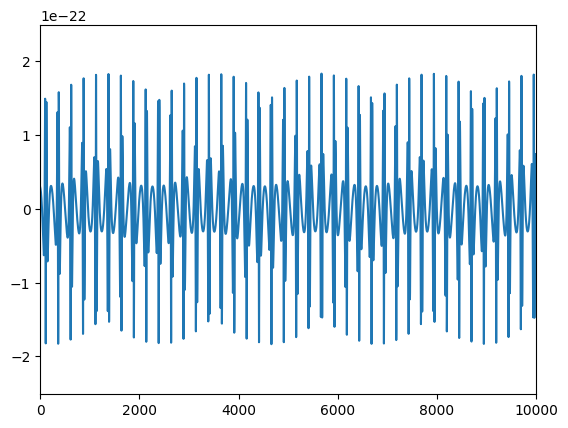

In [13]:
plt.plot(t_eval, waveform.real)
plt.xlim(0, 10000)

In [8]:
# lotsa_waves = jax.vmap(build_waveform, in_axes = (None, None, None, None, 0, None, None, None, None, None, None))

# pvals = jnp.linspace(10., 12., 10)

# outs = lotsa_waves(t_eval, m1, m2, a, pvals, e0, theta, T, l_modes, m_modes, n_modes)

In [9]:
# %timeit build_waveform(t_eval, m1, m2, a, p0, e0, theta, T, l_modes, m_modes, n_modes)

In [10]:
# plt.plot(t_out, coeffs_phase[0,:,0])